## How does ML Works , sample program for linear regression

## 1. Business Understanding

In a car manufacturing company , they want some UI which will have input of HP, SPEED, VOLUME and Weight based on different feature values, how MPG values are laid, if they do manually it is difficult, so they expect a predication ui where user will give inputs then it will predict the CAR MPG. It helps them to design various car models

## 2. Data Collection

Collect the data from business and analyze it, like what attribut need to be predicted(Y). Ok it is MPG, if it is not there ask business

In [25]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from IPython.display import Image
from pickle import dump
from pickle import load
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
cars_data = pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding  

Understand client data like, how many rows and columns, is there any null values, analyze data type etc.

In [6]:
cars_data.shape 

(81, 5)

In [7]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [8]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [10]:
cars_data.describe()#from describe we analyze the data like min and max of each attribute, data distribution

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


 So,what we concluede while data understanding is
1) Total no.of rows and columns
2) Data type of each columns
3) There is no discreate/categorical data
4) All numerical columns, no string columns
5) Analyze the data distribution like how data presented min and max and standared deviation(how far the each value on or before the avg value)

## 3.1 Now Let us check for the assumptions

### 3.1.1 Linearity Test

Compare each input feature to output feature , it should be linear line either it can be directly or indirectly proportion, the line should come as best fitted line

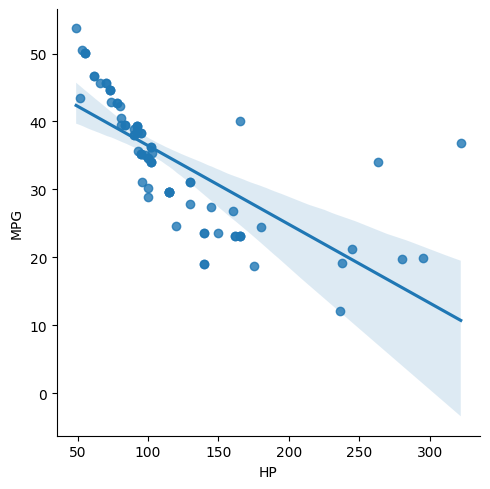

In [3]:
sns.lmplot(data=cars_data, x="HP",y="MPG") #Even we can use scatter plot also, since we have line support we use lmpplot

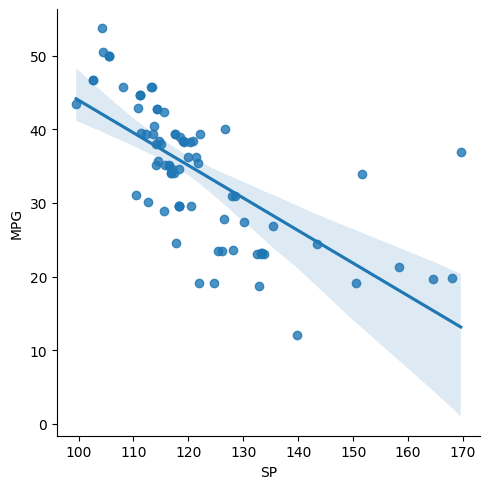

In [4]:
 sns.lmplot(data=cars_data, x="SP",y="MPG")

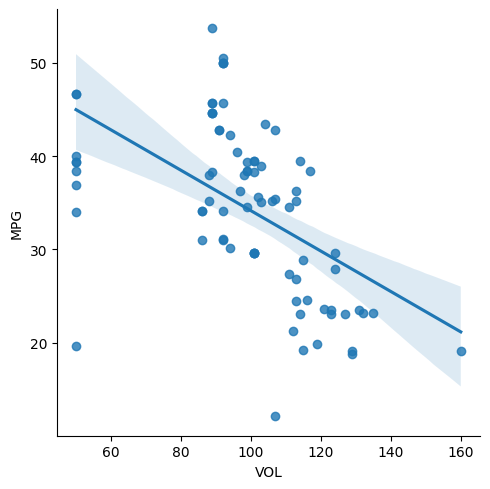

In [26]:
sns.lmplot(data=cars_data, x="VOL",y="MPG")

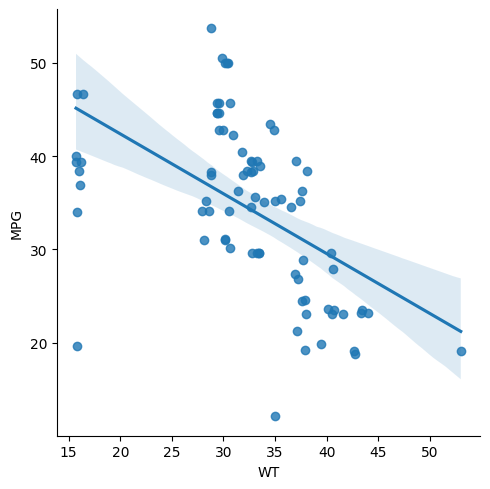

In [27]:
sns.lmplot(data=cars_data, x="WT",y="MPG")

We have analyzed all input with Y, none of them are come with direct line , dots are scatterd very outer to the line. The expectation is atlease all the dots very adjacent to the straight line, the we accept linearity is pass. 
But this we compared all x with y, nothing comes as linearity.
* So , Linearity test is failed

### 3.1.2 Normality test

For normality , we need to see in graph as bell curve like normal distribution, so we can use histrogram

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

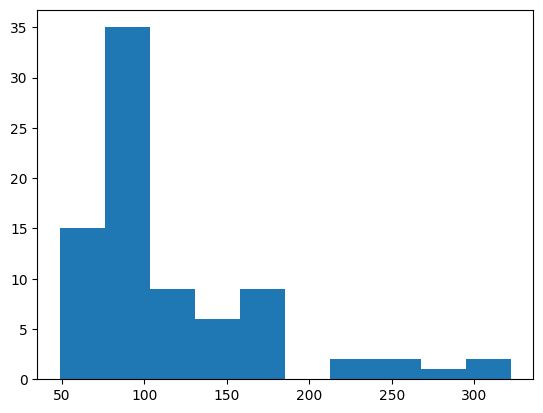

In [29]:
plt.hist(cars_data["HP"])

<Axes: ylabel='Density'>

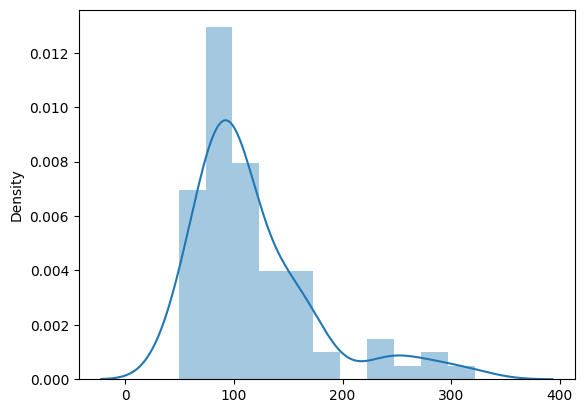

In [34]:
sns.distplot(x=cars_data["HP"])

<Axes: ylabel='Density'>

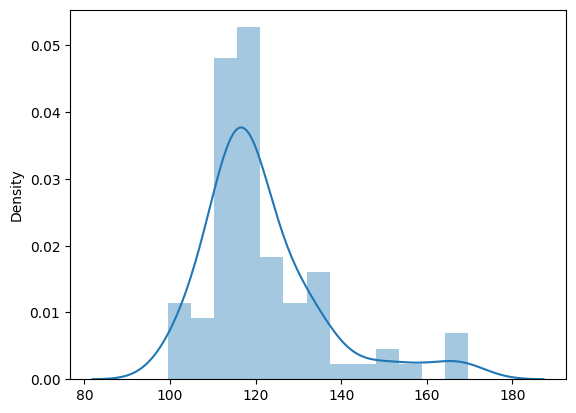

In [36]:
sns.distplot(x=cars_data["SP"])

<Axes: ylabel='Density'>

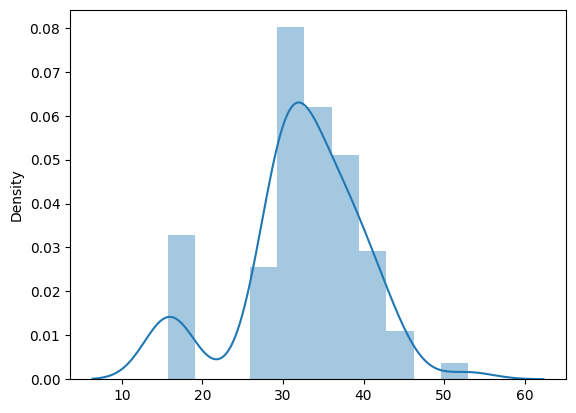

In [37]:
sns.distplot(x=cars_data["WT"])

<Axes: ylabel='Density'>

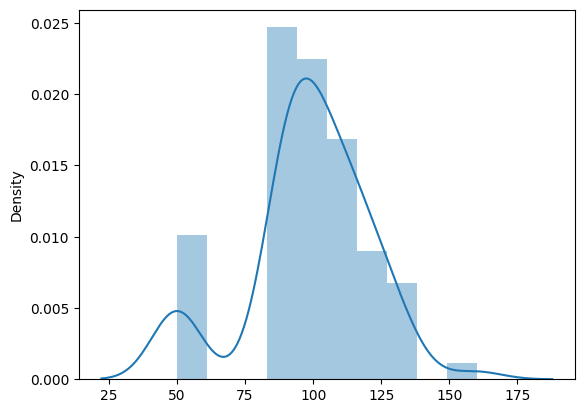

In [38]:
sns.distplot(x=cars_data["VOL"])

Since tail of the line towrds right, then it is right skewed, so none of the input x give normal distribution
* Normality test is failed

## 3.1.3 Correlation Matrix

How strongly each x and yis laid on. To find strenght of relationship we can use correlation matix.

In [50]:
corr_matrix  = cars_data.corr() # It will compute the formula and give co-efficent value, that will describe the relationhsip between two features
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


 So, if you see when you compare two input feature and if it is hightly strong correlation then , 
 * this assumption is failed

Since comparing each pair is difficult, so we can use heatmap chart with color effect

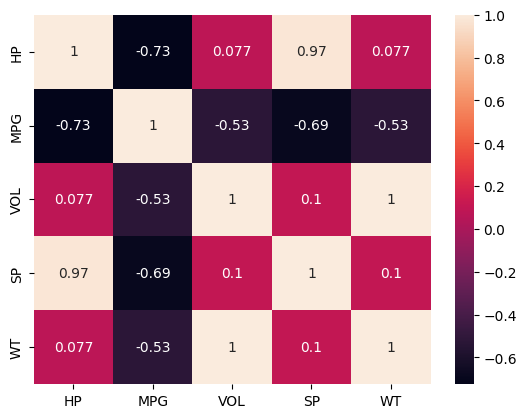

In [53]:
sns.heatmap(data=corr_matrix,annot=True)
plt.show()

Always between input features.
* Note : You know to find MPG we are using HP as well as SP, technically both are same. because if sp or HP increase automaticall MPG drops. So this cases take any one, and ask business to give another set of column if they have like no.of AC

### 3.1.4 Multi Colllinearity test
#### This alread covered in Corrleation matrix
* No Dependency between the input variables

## Homoscadacity and Zero Residual Mean should be checked after building the model

### 3.1.5 Auto Regression
Since given data set does not has date, year , time
* So This check is passed

## 4. Data Preparation

There is nothing to prepare, because all columns are number.
Feature engineering technique can be applied later

In [3]:
x = cars_data[["HP","SP","VOL","WT"]]
y = cars_data["MPG"]

## 5. Model Building

In given dataset we have X and Y so we can go and use linear regression algorithm

In [4]:
# It internally has linear regression algorithm and it will take care to find co-efficeint and draw the best fitted line
linear_model = LinearRegression() 

## 6. Model Traning

In [5]:
#Give data and papers to model
linear_model.fit(x,y)

##  Deliverables M & C
#What is intercept C
# The point where the line crosses the y‑axis (when x=0) is the intercept
linear_model.intercept_ 


np.float64(30.67733585215177)

In [6]:

#What is coefficient(M) Slope
# The slope (coefficient) is the tilt of the line — how much MPG changes when that feature increases by 1 unit.
# For each input one coefficiet is found
linear_model.coef_ 

array([-0.20544372,  0.39562692, -0.33605084,  0.40057409])

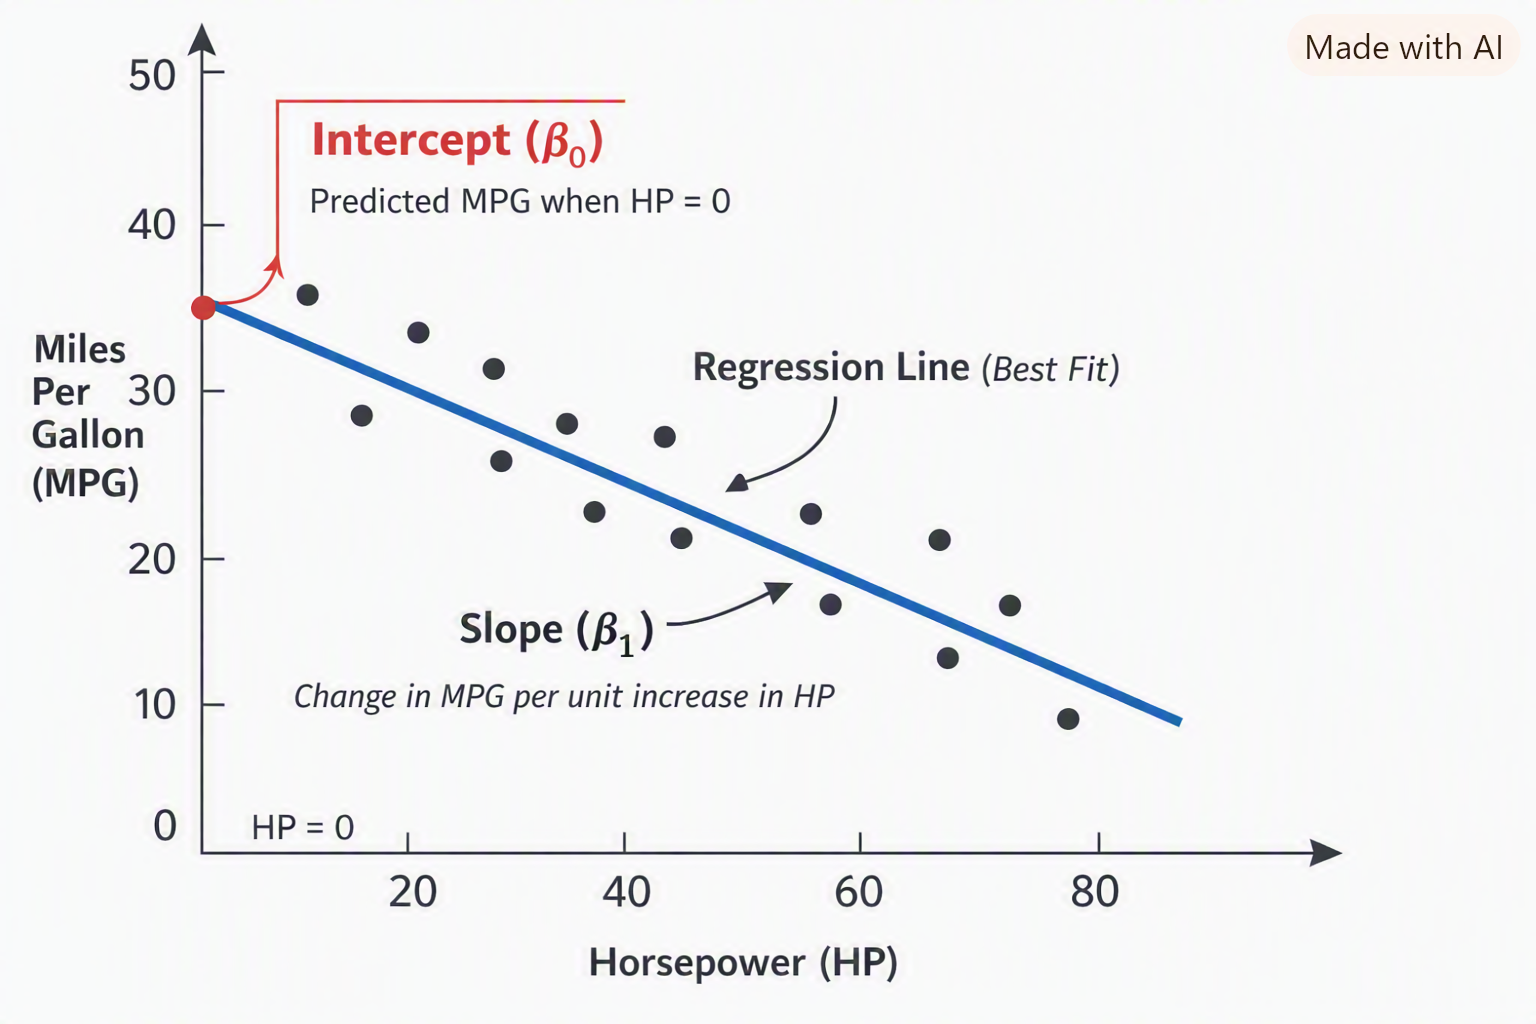

In [9]:
display(Image("car_mileage_linear_regression_graph.png",width=400, height=300))

## 📊 Intercept in Linear Regression

Here’s a diagram to make the **intercept** crystal clear:

- 🔴 **The red dot on the y‑axis is the intercept (\(\beta_0\))**
  - It’s the predicted MPG when HP = 0 (all features = 0 in multiple regression).
  - Notice it’s not zero — it’s a baseline value chosen by the regression algorithm.

- 🔵 **The blue line is the regression line (best fit)**
  - Its slope (\(\beta_1\)) shows how MPG changes for each unit increase in HP.
  - If slope is negative, MPG decreases as HP increases.

---

### 💡 Intuition
- 🧑‍💼 In the **employee salary case**, intercept = base salary when experience = 0.  
- 🚗 In the **car mileage case**, intercept = baseline MPG when HP=0 (hypothetical, since cars don’t really have HP=0).  
- The intercept is simply the **y‑axis crossing point** of the regression line, while the slope is the **tilt** of the line.

---

### ⚙️ Internal Algorithm
- 
The internal linear algorithm will take to find M(Coefficient) & C (Intercept), if the dataset is exactly in linear way then we will get the best fitted line, but if it is non-linear algorithm will take care with error value and finally draw the slope in common.
Example: when emp exp 1 yr, 20K 2yr, 30K, 3yr 10K, then best fit line will not come.


## 7. Model Testing

In [7]:
#Linear model find the y :: y = mx+c

#Give question paper
y_predication = linear_model.predict(x)
y_predication

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

In [ ]:
#Example : 43.44193 is the mileage with the combination input of (HP,SP,VOL,WT), likewise for each row it is returned

In [82]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## 8. Model Evaulation

In [8]:
error = y - y_predication
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

### Apply Evaulation Metrics for Regression model (y Continous data)

#### 1. Mean Absolute Error - On average, how far off are my guesses from the real answer?”
 - if we do find mean of error that is MAE
 - Mean Absolute Error (MAE) is an evaluation metric for regression models that measures the average size of prediction errors in the same units as the target variable, without considering whether the errors are positive or negative. In simple terms, it tells you “on average, how far off are my predictions from the actual values.” Lower MAE means better model performance. 

In [9]:
error.mean()

np.float64(-3.684295666904223e-15)

In [30]:
#now With formula also it should be simialr
mean_absolute_error(y,y_predication) # Same units

3.2679682854207996

In [25]:
#Since the avg 3.68 is ok

Suppose if my output MAE  is 20.6

Ah, now we’re getting into the heart of interpretation, Kannan 👍.  

If your **MAE comes out to 20.6 MPG**, here’s how to think about it:  

---

##### 🔎 Step 1: Compare to the Scale of Data
- If your cars’ MPG values range between **10–40 MPG**, then an average error of **20.6 MPG** is **huge** — basically, the model is missing by half the possible range. That means the predictions are not useful.  
- If your MPG values range between **100–500 MPG** (hypothetically, say futuristic vehicles), then 20.6 might be **reasonable**, because it’s only ~5% of the scale.  

---

##### 🔎 Step 2: Compare to Baseline
- Suppose the baseline model (predicting the mean MPG for all cars) gives MAE = 22.  
- If your regression model gives MAE = 20.6, it’s only a **tiny improvement**.  
- That suggests your predictors (HP, SP, VOL, WT) are not explaining MPG very well.  

---

##### 🔎 Step 3: Business Context
- For **engineering design or fuel efficiency studies**, being off by 20 MPG is unacceptable.  
- For a **rough consumer estimate** (like “low mileage vs high mileage”), it might still give some directional insight, but not precise.  

---

##### ✅ Conclusion
- **MAE = 20.6 MPG is generally considered poor** if your dataset is in the normal car MPG range (10–40).  
- It signals that the model is not capturing the relationship well, or that the predictors chosen (HP, SP, VOL, WT) don’t explain MPG strongly enough.  

---

👉 In practice, you’d try:  
- Adding/removing predictors.  
- Checking for nonlinear relationships.  
- Using transformations (like log of WT or HP).  
- Trying other models (decision trees, random forest).  

---

Would you like me to show you a **Python demo** where we calculate MAE for your car dataset and compare it against a baseline model, so you can *see* why 20.6 is considered poor in this context?

#### 2. Mean Squeared error

MSE is almost the same idea as MAE, but instead of just taking the distance (absolute error),  
we take the **distance squared**.

🎯 Imagine you’re throwing darts at a target:

- If you miss by **2 cm**, squaring makes it **4**.  
- If you miss by **5 cm**, squaring makes it **25**.  

So, big mistakes suddenly look MUCH bigger because squaring magnifies them.


In [31]:
mean_squared_error(y,y_predication) # output Squared Units

18.897141152343103

#### 3. Root Mean Squared Error

- MSE → gives you the average squared error. Because of squaring, the number is in squared units (like cm², rupees²). That makes it bigger and harder to interpret.

- RMSE → takes the square root of MSE, so the number comes back to the original units (cm, rupees, etc.). This makes it smaller and easier to understand.

In [34]:
root_mean_squared_error(y,y_predication) # output Normalized units

4.347084212704316

#### 4. R2 Score
##### 📊 Understanding R² Score (Coefficient of Determination)

R² tells us **how well our model’s predictions match the actual data**.  
Think of it as a **report card score** for your regression model:

- **R² = 1 (100%)** → Perfect! Predictions match the data exactly.  
- **R² = 0** → Model is no better than just guessing the average.  
- **R² < 0** → Model is worse than guessing the average.  

---

##### 🧩 Formula


👉 In simple words: R² compares your model’s errors to just guessing the average.


In [37]:
r2_score(y,y_predication)

0.7705372737359844

In [39]:
#model guess is 77% avg nearly, so it is fine

##### 5. Adjusted R2 score


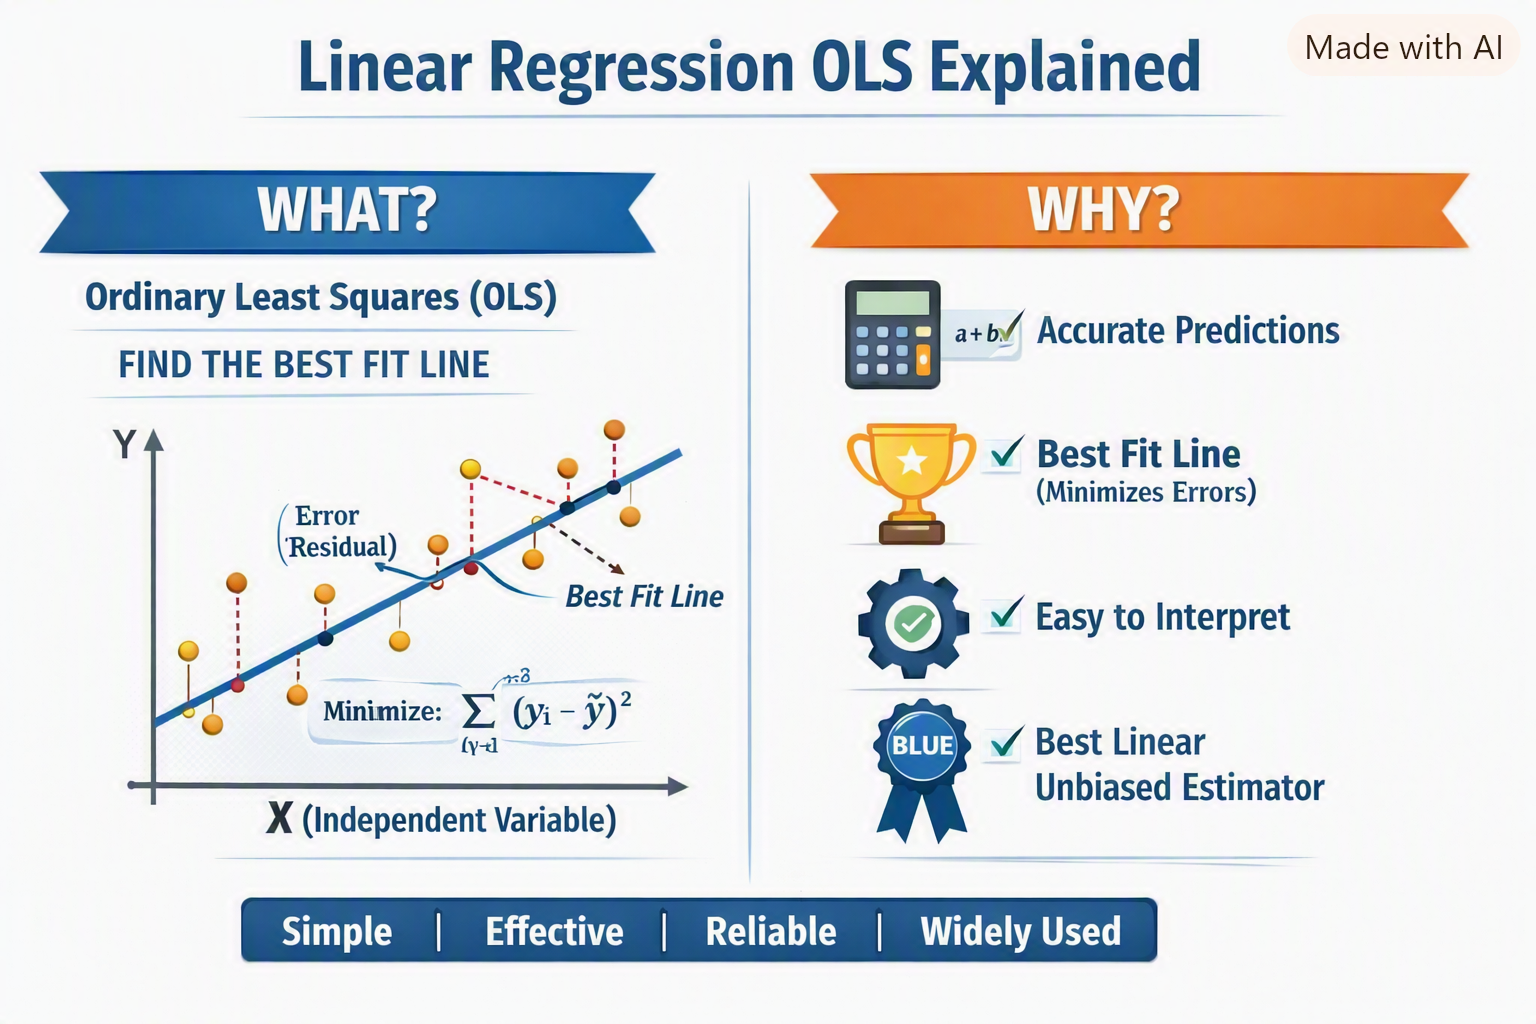

In [12]:
display(Image("linera_regression_best_fit_line.png",width=700, height=500))

👉 The left side shows what OLS does: it finds the best fit line by minimizing the sum of squared errors (the red dashed lines between actual data points and the regression line).

👉 The right side shows why OLS is useful: accurate predictions, easy interpretation, and the fact that it gives the Best Linear Unbiased Estimator (BLUE) when assumptions hold.

To form best fitted line OLS follows 2 techniques
1) sklearn.linearmodel -> Linear regression does not have adjusted r2_score
2) statsmodel -> linear regression has adjusted r2 score

##### To see adjusted R2 score , we are using OLS technique from statsmodels formula

##### Building stats model

In [15]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP+WT", data = cars_data).fit()

In [17]:
print("R2 score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score: ", linear_stats_model.rsquared_adj.round(4))

R2 score: 0.7705 
Adjusted R2 Score:  0.7585


In [18]:
linear_stats_model = smf.ols(formula="MPG ~ HP", data = cars_data).fit()
print("R2 score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score: ", linear_stats_model.rsquared_adj.round(4))

R2 score: 0.5257 
Adjusted R2 Score:  0.5197


In [19]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL", data = cars_data).fit()
print("R2 score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score: ", linear_stats_model.rsquared_adj.round(4))

R2 score: 0.7507 
Adjusted R2 Score:  0.7443


#Note:
Actual Definition of Adjust R2 score : 74.43
- 74.43 percentage my model is contributed variance of output , that means
- HP + VOL this two together how much is contributed towards variance, since HP and VOL has more variance our predication is stable 
- suppose still if we take one more, then vairance towards predication should be high, if not try to collect new feature
- ideally Adjusted R2 score is expected to go near 1,

In [20]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP", data = cars_data).fit()
print("R2 score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score: ", linear_stats_model.rsquared_adj.round(4))

R2 score: 0.7704 
Adjusted R2 Score:  0.7614


In [21]:
linear_stats_model = smf.ols(formula="MPG ~ HP+VOL+SP+WT", data = cars_data).fit()
print("R2 score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score: ", linear_stats_model.rsquared_adj.round(4))

R2 score: 0.7705 
Adjusted R2 Score:  0.7585


In the above, 4 times we repeated the model and see the R2 score and adjusted R2 score values, you know HP+VOL are two different independent variable at
the same time when we add HP + VOL + SP + WT here VOL and WT is simialr varible, this case R2 will increase but Adjust R2 score will not increase, so instead
we can go and ask the business for some other essestional feature like no.of AC like that

- So finally this adjust r2 score formula helps to track how much better predication we get while we add an additional features one by one, 

- Refer Coach R2 and adj_R2_score doucment formula
- When the no.of input feature is increasing, then in numerator the sum resdual error will decrease, and sum of total value is increasing, so R2 score will be increaed

NOTE:
- If your dataset has strong relationships between predictors and the target, both R² and Adjusted R² will be high.

- If your dataset has weak or noisy relationships, R² might look okay, but Adjusted R² will drop once it penalizes those extra, unhelpful variables.

- If you add a variable that truly explains variation in your data, Adjusted R² increases. If not, it decreases — showing that the data didn’t support that variable.

## Now let's peform the Homoscedasticity Test
#### Homoscedasticity means that the variance of the errors (residuals) in a regression model is constant across all levels of the independent variables

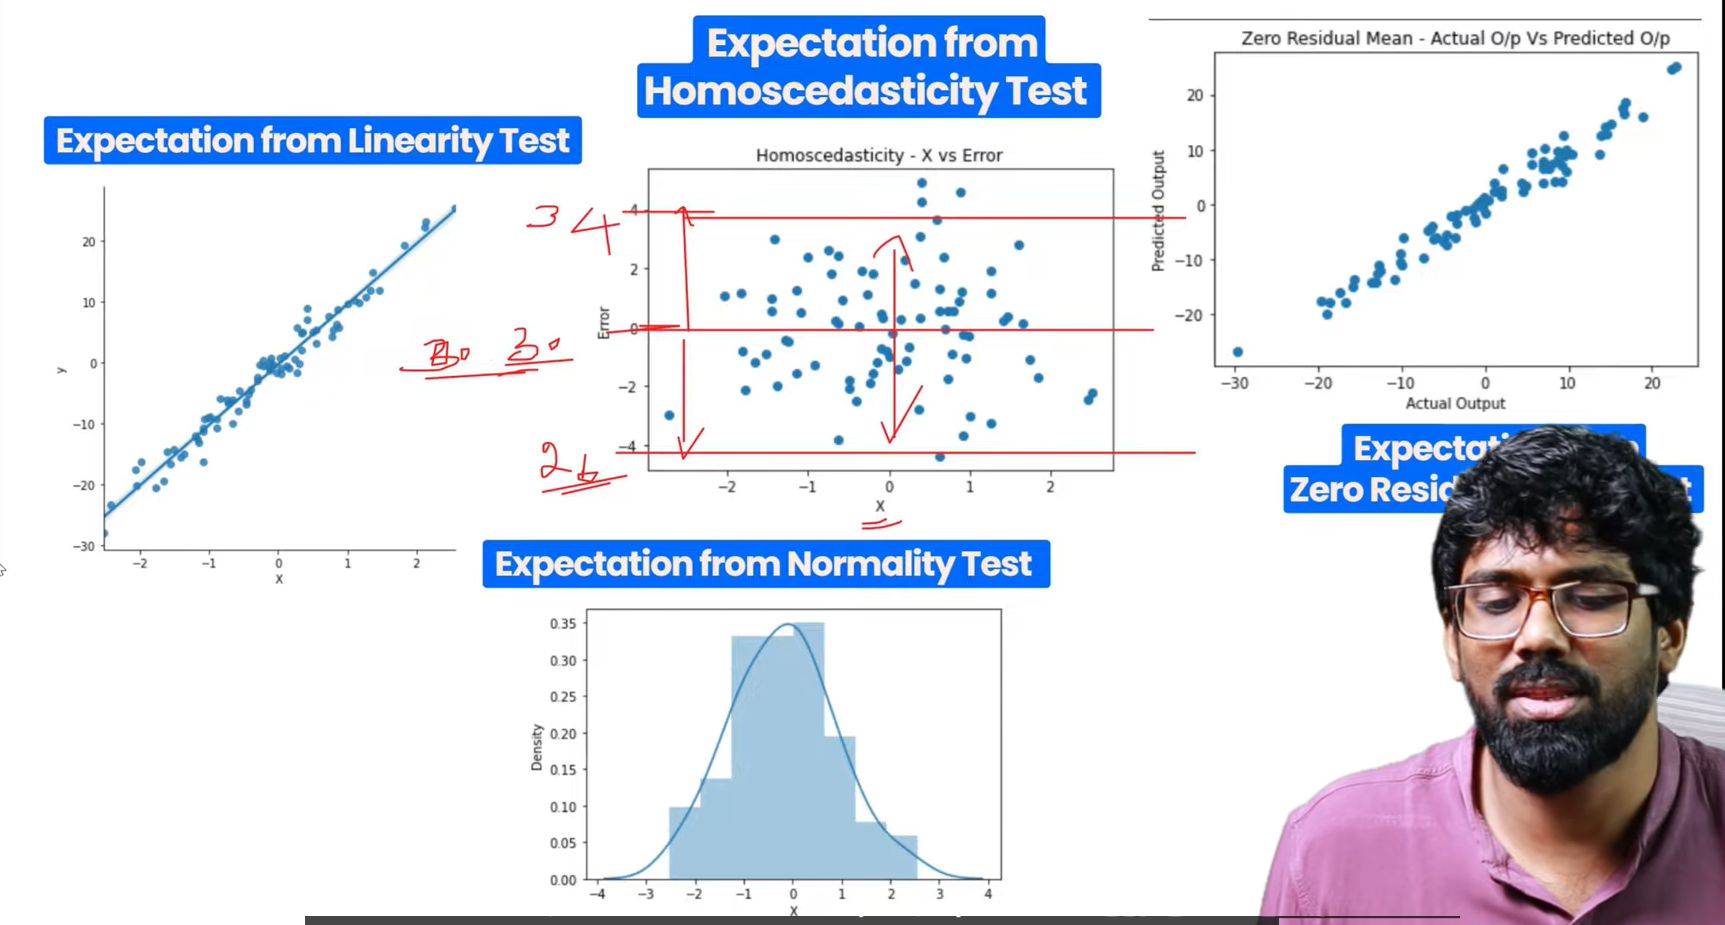

In [28]:
display(Image("Homo.png",width=600, height=400))

When X is increase or Decrease, MPG fallen 34 or 26 , or max and min coefficent value fall +4 or -4 , so so homoscedasticity passed

<Axes: xlabel='HP', ylabel='MPG'>

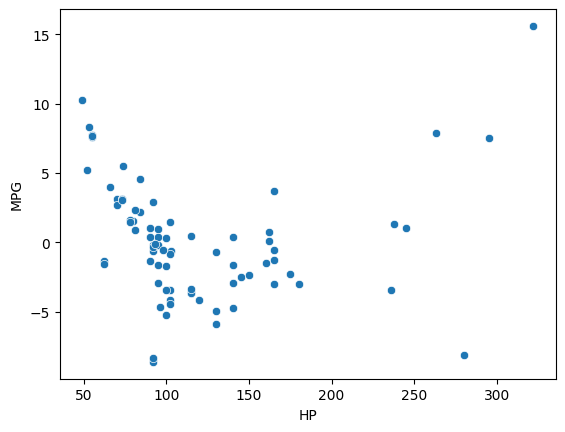

In [30]:
sns.scatterplot(data = cars_data,x="HP",y=error)

#### When we check with scatterplot there is no similar variance yaxis above zero going like 5, 10 15, but below -5 , so homoscedasticity is failed

# Zero Residual Mean test

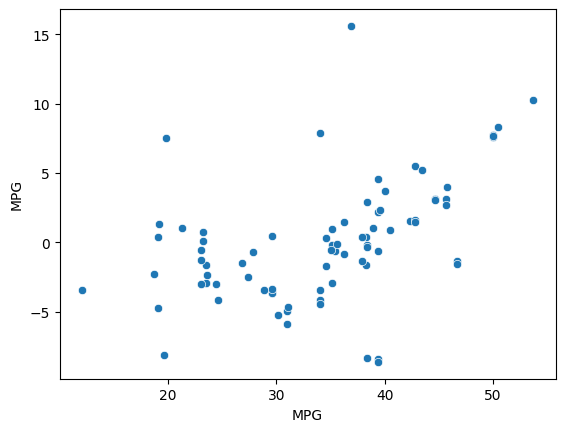

In [33]:
sns.scatterplot(x= cars_data["MPG"],y=error)
plt.show()

Finally Zero Resisual Mean test also failed , becuase there too much scattered, so when you draw line there are too much variance so this is failed


# 📊 What Does "Zero Residual" Mean?

- A **residual** is the difference between the actual value ((Y_i)) and the predicted value (y_p) from a regression model:

  

ei = y_i - y_p


- If the **residual = 0**, it means:
  - The model’s prediction exactly matches the observed data point.
  - There is **no error** for that observation.
  - The point lies **right on the regression line (or plane)**.

---

## 🔎 Example

Suppose we predict salary based on years of experience:



salary = 30000 + 5000 * Exp



- Actual salary = ₹40,000  
- Experience = 2 years → Predicted salary = (30000 + 5000 * 2 = 40000)  
- Residual = 40000

👉 Here, the model perfectly predicted the salary, so the residual is zero.

---

## ⚡ Key Insight

- **Zero residual** doesn’t mean the whole model is perfect — it just means that **for that one data point**, the prediction was spot on.
- In practice, most residuals are not zero. Regression minimizes the **sum of squared residuals**, so:
  - Some points will have small errors,
  - Some larger,
  - And occasionally a few will be exactly zero.


## Finally All test is failed

## 9. Model Deployment

#####  To expose the linear model as intelligence file, because that give the predicted answer by x

In [12]:
dump(obj = linear_model,file=open("linear_intelligence_file.pkl",mode="wb"))

##### To import pickle file in the backend code 

In [13]:
linear_intel_pkl = load(file = open("linear_intelligence_file.pkl",mode="rb"))
linear_intel_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
linear_intel_pkl.predict(x)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

In [49]:
x1 = [[34,45,56,67]]
linear_intel_pkl.predict(x1)

array([49.51507772])

### With Train test spilt example

In [37]:
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20,shuffle=True, random_state=34,)

In [27]:
x_train

,HP,SP,VOL,WT
17,92,117.598513,50,16.194122
52,115,120.404312,124,40.398164
16,78,114.369293,91,29.535784
39,130,128.461264,92,30.115434
22,95,120.288996,101,32.675828
...,...,...,...,...
11,92,117.598513,50,15.753535
69,245,158.300669,112,37.141733
35,90,115.013085,98,31.911223
68,165,133.312342,123,40.472042


In [30]:
y_train

,HP,SP,VOL,WT
59,100,115.576579,115,37.662874
49,115,118.288996,101,33.458472
7,62,102.598513,50,15.847758
27,92,119.105055,99,32.835069
74,140,121.864163,129,42.618698
61,120,117.668550,116,37.860411
64,150,128.128401,121,40.159482
12,92,122.105055,99,32.813592
44,93,114.380966,102,33.078632
30,84,113.484609,114,37.042350


In [31]:
x_test

17    39.354094
52    29.629936
16    42.789909
39    31.014131
22    38.310606
        ...    
11    39.354094
69    21.273708
35    37.958743
68    23.103172
33    36.285456
Name: MPG, Length: 64, dtype: float64

In [32]:
y_test

59    28.860225
49    29.629936
7     46.716554
27    38.411003
74    19.086341
61    24.609132
64    23.605158
12    39.354094
44    35.643558
30    39.431235
0     53.700681
15    44.652834
3     45.696322
48    31.014131
78    34.000000
77    19.197888
1     50.013401
Name: MPG, dtype: float64

#### Model Training

In [38]:
# Combine x_train and y_train back into one DataFrame
train_data = pd.concat([x_train, y_train], axis=1)
linear_stats_model_2 = smf.ols(formula="MPG ~ HP+VOL+SP+WT", data = train_data).fit()

#### Model Testing

In [40]:
y_predicated_train = linear_stats_model_2.predict(x_train)
y_predicated_train

17    46.754626
52    29.357921
16    40.595311
39    35.553264
22    37.450590
        ...    
11    46.381659
69    20.507483
35    37.201809
68    24.768487
33    35.044203
Length: 64, dtype: float64

In [41]:
y_predicated_test = linear_stats_model_2.predict(x_test)
y_predicated_test

59    32.393946
49    33.360206
7     46.789915
27    38.666016
74    24.471758
61    28.890130
64    26.471570
12    39.781314
44    35.494911
30    34.740242
0     42.816958
15    41.378201
3     42.315028
48    36.398842
78    25.064812
77    18.257079
1     42.150448
dtype: float64

In [43]:
error = y_test - y_predicated_test
error

59    -3.533721
49    -3.730271
7     -0.073361
27    -0.255013
74    -5.385418
61    -4.280998
64    -2.866412
12    -0.427220
44     0.148646
30     4.690993
0     10.883723
15     3.274633
3      3.381295
48    -5.384712
78     8.935188
77     0.940808
1      7.862953
dtype: float64

##### Test Evaulation

In [42]:
y_predicated_train_MAE = mean_absolute_error(y_train,y_predicated_train) # Same units
y_predicated_train_MAE

3.1298305777220126

In [44]:
y_predicated_test_MAE = mean_absolute_error(y_test,y_predicated_test) # Same units
y_predicated_test_MAE

3.885609698062918

##### So, our trained vs test outcome with simialr prediction